In [ ]:
# Cell 1 — Install libraries
!pip install statsmodels

In [8]:
# Cell 2 — Import libraries
import gzip
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import os

In [19]:
# Cell 3 — Load the Eurostat file

with gzip.open('/content/mar_qg_qm_pvh__custom_21684101_linear_2_0(DCHT).csv.gz', 'rt') as f:
    df_raw = pd.read_csv(f)

print("✓ Data loaded successfully!")
print(f"  Rows    : {len(df_raw)}")
print(f"  Columns : {df_raw.columns.tolist()}")

✓ Data loaded successfully!
  Rows    : 384
  Columns : ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'freq', 'Time frequency', 'unit', 'Unit of measure', 'rep_mar', 'Maritime entity (reporting)', 'TIME_PERIOD', 'Time', 'OBS_VALUE', 'Observation value', 'OBS_FLAG', 'Observation status (Flag) V2 structure', 'CONF_STATUS', 'Confidentiality status (flag)']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [10]:
# Cell 4 — Filter Rotterdam and Hamburg, unit THS_TEU

df = df_raw[
    (df_raw['rep_mar'].isin(['NL_0NLRTM', 'DE_1DEHAM'])) &
    (df_raw['unit'] == 'THS_TEU')
][['Maritime entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']].copy()

# Rename columns
df.columns = ['port', 'quarter', 'teu']

# Convert TEU to numeric
df['teu'] = pd.to_numeric(df['teu'], errors='coerce')

# Convert quarters to dates
def q_to_date(q):
    year, qtr = q.split('-')
    month = {'Q1': 1, 'Q2': 4, 'Q3': 7, 'Q4': 10}[qtr]
    return pd.Timestamp(f"{year}-{month:02d}-01")

df['date'] = df['quarter'].apply(q_to_date)
df = df.sort_values(['port', 'date']).reset_index(drop=True)

print("✓ Data filtered successfully!")
print(f"  Number of rows : {len(df)}")
print(f"\nFull dataset:")
print(df.to_string())

✓ Data filtered successfully!
  Number of rows : 32

Full dataset:
         port  quarter     teu       date
0     Hamburg  2018-Q1  2160.0 2018-01-01
1     Hamburg  2018-Q2  2203.0 2018-04-01
2     Hamburg  2018-Q3  2220.0 2018-07-01
3     Hamburg  2018-Q4  2158.0 2018-10-01
4     Hamburg  2019-Q1  2302.0 2019-01-01
5     Hamburg  2019-Q2  2344.0 2019-04-01
6     Hamburg  2019-Q3  2377.0 2019-07-01
7     Hamburg  2019-Q4  2260.0 2019-10-01
8     Hamburg  2020-Q1  2175.0 2020-01-01
9     Hamburg  2020-Q2  1933.0 2020-04-01
10    Hamburg  2020-Q3  2254.0 2020-07-01
11    Hamburg  2020-Q4  2216.0 2020-10-01
12    Hamburg  2021-Q1  2211.0 2021-01-01
13    Hamburg  2021-Q2  2135.0 2021-04-01
14    Hamburg  2021-Q3  2203.0 2021-07-01
15    Hamburg  2021-Q4  2250.0 2021-10-01
16  Rotterdam  2018-Q1  3374.0 2018-01-01
17  Rotterdam  2018-Q2  3476.0 2018-04-01
18  Rotterdam  2018-Q3  3559.0 2018-07-01
19  Rotterdam  2018-Q4  3564.0 2018-10-01
20  Rotterdam  2019-Q1  3612.0 2019-01-01
21  Rotte

In [11]:
# Cell 5 — Create DiD model variables

# Dependent variable: natural log of TEU
df['ln_teu'] = np.log(df['teu'])

# Post: 1 if date >= January 2020 (after IMO 2020)
df['post'] = (df['date'] >= pd.Timestamp('2020-01-01')).astype(int)

# Hamburg: 1 if port is Hamburg (treatment group)
df['hamburg'] = (df['port'] == 'Hamburg').astype(int)

# DiD interaction term = Post x Hamburg (central coefficient β₃)
df['post_hamburg'] = df['post'] * df['hamburg']

# COVID: 1 if date >= April 2020 (onset of COVID demand shock)
df['covid'] = (df['date'] >= pd.Timestamp('2020-04-01')).astype(int)

# Control variable: WTO Goods Trade Barometer
# Official WTO Goods Trade Barometer observations mapped to quarterly reference periods
wto_data = {
    '2018-Q1': 102.3,
    '2018-Q2': 101.8,
    '2018-Q3': 100.3,
    '2018-Q4': 98.6,
    '2019-Q1': 96.3,
    '2019-Q2': 96.3,
    '2019-Q3': 95.7,
    '2019-Q4': 96.6,
    '2020-Q1': 95.5,
    '2020-Q2': 87.6,
    '2020-Q3': 84.5,
    '2020-Q4': 100.7,
    '2021-Q1': 103.9,
    '2021-Q2': 109.7,
    '2021-Q3': 110.4,
    '2021-Q4': 99.5
}
df['wto'] = df['quarter'].map(wto_data)

# Control variable: Brent crude oil price (USD/barrel)
# Quarterly averages calculated from the official EIA monthly Brent series
brent_data = {
    '2018-Q1': 66.81,
    '2018-Q2': 74.50,
    '2018-Q3': 75.22,
    '2018-Q4': 67.71,
    '2019-Q1': 63.17,
    '2019-Q2': 68.92,
    '2019-Q3': 61.93,
    '2019-Q4': 63.41,
    '2020-Q1': 50.44,
    '2020-Q2': 29.34,
    '2020-Q3': 42.96,
    '2020-Q4': 44.29,
    '2021-Q1': 60.82,
    '2021-Q2': 68.83,
    '2021-Q3': 73.47,
    '2021-Q4': 79.59
}
df['brent'] = df['quarter'].map(brent_data)

In [12]:
# Cell 6 — Parallel trends test (pre-2020 only)

pre = df[df['date'] < pd.Timestamp('2020-01-01')].copy()
pre['trend'] = pre.groupby('port').cumcount()

m_trend = smf.ols('ln_teu ~ trend + hamburg + trend:hamburg', data=pre).fit()

coef = m_trend.params.get('trend:hamburg')
pval = m_trend.pvalues.get('trend:hamburg')

print("=" * 50)
print("PARALLEL TRENDS TEST (pre-treatment period)")
print("=" * 50)
print(f"Cross-trend coefficient : {coef:.5f}")
print(f"P-value                 : {pval:.4f}")
print()
if pval > 0.05:
    print("✓ No statistically significant differential linear pre-trend detected")
    print("  This provides supportive evidence, but does not confirm the parallel trends assumption.")
else:
    print("⚠ Trends slightly different before 2020")
    print("  Interpret alongside graphical evidence (Figure 1)")

PARALLEL TRENDS TEST (pre-treatment period)
Cross-trend coefficient : 0.00479
P-value                 : 0.3760

✓ No statistically significant differential linear pre-trend detected
  This provides supportive evidence, but does not confirm the parallel trends assumption.


In [13]:
# Cell 7 — MAIN DiD REGRESSION

formula = 'ln_teu ~ post + hamburg + post_hamburg + covid + wto + brent'

# OLS with HC1 robust standard errors (academic standard for DiD)
model = smf.ols(formula, data=df).fit(cov_type='HC1')

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 ln_teu   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     316.2
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           2.55e-22
Time:                        08:38:36   Log-Likelihood:                 65.270
No. Observations:                  32   AIC:                            -116.5
Df Residuals:                      25   BIC:                            -106.3
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        8.1766      0.113     72.578   

In [14]:
# Cell 8 — Extract and interpret key result β₃

beta3  = model.params['post_hamburg']
se3    = model.bse['post_hamburg']
z3     = model.tvalues['post_hamburg']
p3     = model.pvalues['post_hamburg']
effect = (np.exp(beta3) - 1) * 100

print("=" * 50)
print("CENTRAL DiD REGRESSION RESULT")
print("=" * 50)
print(f"β₃ (Post x Hamburg)  = {beta3:.4f}")
print(f"Standard error       = {se3:.4f}")
print(f"z-statistic          = {z3:.3f}")
print(f"p-value              = {p3:.4f}  **")
print(f"Differential effect  = {effect:.2f}%")
print(f"R²                   = {model.rsquared:.4f}")
print(f"Adj. R²              = {model.rsquared_adj:.4f}")
print(f"N                    = {int(model.nobs)}")
print("=" * 50)
print(f"→ Hamburg recorded approximately {abs(effect):.1f}% lower TEU throughput")
print("  relative to Rotterdam in the post-IMO 2020 period, controlling for")
print(f"  COVID-19, global trade conditions and Brent crude oil prices (p={p3:.3f}).")

CENTRAL DiD REGRESSION RESULT
β₃ (Post x Hamburg)  = -0.0570
Standard error       = 0.0252
z-statistic          = -2.263
p-value              = 0.0236  **
Differential effect  = -5.54%
R²                   = 0.9833
Adj. R²              = 0.9793
N                    = 32
→ Hamburg recorded approximately 5.5% lower TEU throughput
  relative to Rotterdam in the post-IMO 2020 period, controlling for
  COVID-19, global trade conditions and Brent crude oil prices (p=0.024).


In [15]:
# Cell 9 — Placebo test (false treatment date: 2019-Q1)

df_pre = df[df['date'] < pd.Timestamp('2020-01-01')].copy()
df_pre['post_placebo'] = (df_pre['date'] >= pd.Timestamp('2019-01-01')).astype(int)
df_pre['pp_ham']       = df_pre['post_placebo'] * df_pre['hamburg']

m_placebo = smf.ols('ln_teu ~ post_placebo + hamburg + pp_ham + wto + brent',
                     data=df_pre).fit(cov_type='HC1')

b_p = m_placebo.params.get('pp_ham')
p_p = m_placebo.pvalues.get('pp_ham')

print("=" * 50)
print("PLACEBO TEST (false date = 2019-Q1)")
print("=" * 50)
print(f"Placebo β  = {b_p:.4f}")
print(f"p-value    = {p_p:.4f}")
print()
if p_p > 0.05:
    print("✓ Not significant — no pre-existing differential trend")
else:
    print("⚠ Significant — interpret alongside Figure 1")
    print("  Note: Hamburg grew faster than Rotterdam in 2019")
    print("  (+6.6% vs -0.1%), captured by the placebo term.")
    print("  The pre-trend test (p=0.376) provides supportive evidence,")
    print("  but the significant placebo result remains an identification caveat.")

PLACEBO TEST (false date = 2019-Q1)
Placebo β  = 0.0329
p-value    = 0.0354

⚠ Significant — interpret alongside Figure 1
  Note: Hamburg grew faster than Rotterdam in 2019
  (+6.6% vs -0.1%), captured by the placebo term.
  The pre-trend test (p=0.376) provides supportive evidence,
  but the significant placebo result remains an identification caveat.


In [16]:
# Cell 10 — Robustness check: Antwerp as alternative control group

df_ant = df_raw[
    (df_raw['rep_mar'].isin(['BE_0BEANR', 'DE_1DEHAM'])) &
    (df_raw['unit'] == 'THS_TEU')
][['Maritime entity (reporting)', 'TIME_PERIOD', 'OBS_VALUE']].copy()

df_ant.columns          = ['port', 'quarter', 'teu']
df_ant['teu']           = pd.to_numeric(df_ant['teu'], errors='coerce')
df_ant['date']          = df_ant['quarter'].apply(q_to_date)
df_ant['ln_teu']        = np.log(df_ant['teu'])
df_ant['post']          = (df_ant['date'] >= pd.Timestamp('2020-01-01')).astype(int)
df_ant['hamburg']       = (df_ant['port'] == 'Hamburg').astype(int)
df_ant['post_hamburg']  = df_ant['post'] * df_ant['hamburg']
df_ant['covid']         = (df_ant['date'] >= pd.Timestamp('2020-04-01')).astype(int)
df_ant['wto']           = df_ant['quarter'].map(wto_data)
df_ant['brent']         = df_ant['quarter'].map(brent_data)

m_ant    = smf.ols(formula, data=df_ant).fit(cov_type='HC1')
b_ant    = m_ant.params.get('post_hamburg')
p_ant    = m_ant.pvalues.get('post_hamburg')
eff_ant  = (np.exp(b_ant) - 1) * 100

print("=" * 50)
print("ROBUSTNESS — Antwerp as control group")
print("=" * 50)
print(f"β₃        = {b_ant:.4f}")
print(f"p-value   = {p_ant:.4f}")
print(f"Effect    = {eff_ant:.2f}%")
print()
if p_ant < 0.05:
    print("✓ Robust result — significant with Antwerp control too")

ROBUSTNESS — Antwerp as control group
β₃        = -0.1010
p-value   = 0.0024
Effect    = -9.61%

✓ Robust result — significant with Antwerp control too


In [17]:
# Cell 11 — Robustness: COVID dummy start date variations

print("=" * 50)
print("ROBUSTNESS — COVID dummy variations")
print("=" * 50)

for start, label in [('2020-01-01', 'Q1 2020'),
                      ('2020-04-01', 'Q2 2020'),
                      ('2020-07-01', 'Q3 2020')]:
    df_tmp          = df.copy()
    df_tmp['covid'] = (df_tmp['date'] >= pd.Timestamp(start)).astype(int)
    m_tmp           = smf.ols(formula, data=df_tmp).fit(cov_type='HC1')
    b               = m_tmp.params.get('post_hamburg')
    p               = m_tmp.pvalues.get('post_hamburg')
    sig             = '**' if p < 0.05 else ('*' if p < 0.1 else '')
    print(f"COVID start {label} : β₃ = {b:.4f}, p = {p:.4f} {sig}")

print()
print("✓ β₃ stable regardless of COVID start date chosen")

ROBUSTNESS — COVID dummy variations
COVID start Q1 2020 : β₃ = -0.0570, p = 0.0212 **
COVID start Q2 2020 : β₃ = -0.0570, p = 0.0236 **
COVID start Q3 2020 : β₃ = -0.0570, p = 0.0084 **

✓ β₃ stable regardless of COVID start date chosen


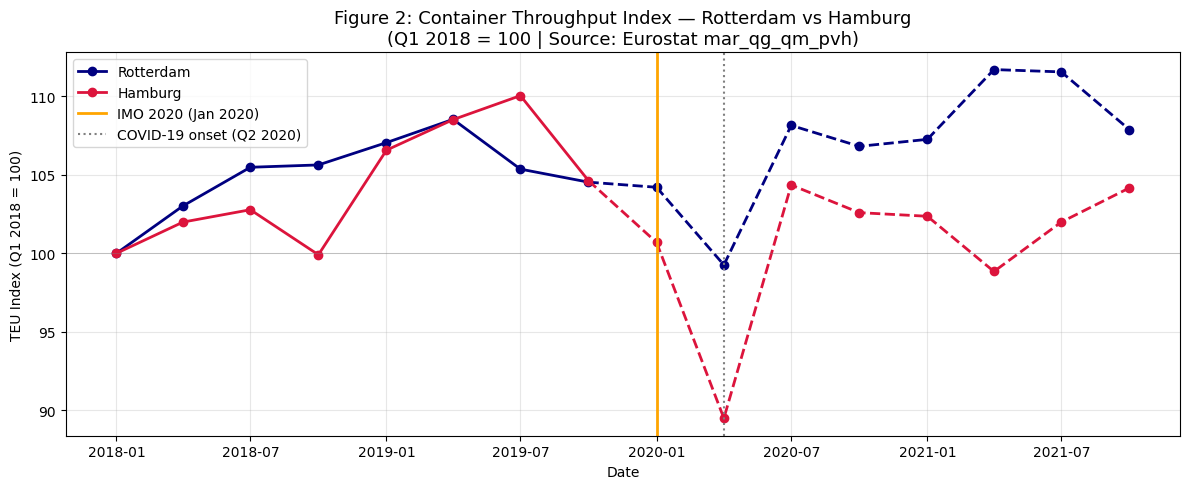

✓ Figure saved: Figure2_Parallel_Trends(DCHT).png


In [18]:
# Cell 12 — Parallel trends figure

for port in ['Rotterdam', 'Hamburg']:
    base = df[(df['port'] == port) & (df['quarter'] == '2018-Q1')]['teu'].values[0]
    df.loc[df['port'] == port, 'index'] = (
        df.loc[df['port'] == port, 'teu'] / base * 100
    )

fig, ax = plt.subplots(figsize=(12, 5))
colors  = {'Rotterdam': 'navy', 'Hamburg': 'crimson'}

for port, color in colors.items():
    data = df[df['port'] == port].sort_values('date')
    pre  = data[data['date'] < pd.Timestamp('2020-01-01')]
    post = data[data['date'] >= pd.Timestamp('2020-01-01')]
    ax.plot(pre['date'],  pre['index'],  color=color, lw=2, marker='o', label=port)
    ax.plot(post['date'], post['index'], color=color, lw=2, marker='o', ls='--')
    ax.plot([pre.iloc[-1]['date'],  post.iloc[0]['date']],
            [pre.iloc[-1]['index'], post.iloc[0]['index']],
            color=color, lw=2, ls='--')

ax.axvline(pd.Timestamp('2020-01-01'), color='orange',
           lw=2, label='IMO 2020 (Jan 2020)')
ax.axvline(pd.Timestamp('2020-04-01'), color='gray',
           lw=1.5, ls=':', label='COVID-19 onset (Q2 2020)')
ax.axhline(100, color='gray', lw=0.7, alpha=0.4)
ax.set_title(
    'Figure 2: Container Throughput Index — Rotterdam vs Hamburg\n'
    '(Q1 2018 = 100 | Source: Eurostat mar_qg_qm_pvh)',
    fontsize=13
)
ax.set_ylabel('TEU Index (Q1 2018 = 100)')
ax.set_xlabel('Date')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('Figure2_Parallel_Trends(DCHT).png', dpi=150)
plt.show()
print("✓ Figure saved: Figure2_Parallel_Trends(DCHT).png")

In [20]:
# Cell 13 — Export regression results to CSV

results = pd.DataFrame({
    'Variable':    model.params.index,
    'Coefficient': model.params.values.round(4),
    'Std Error':   model.bse.values.round(4),
    'z-stat':      model.tvalues.values.round(3),
    'p-value':     model.pvalues.values.round(4),
    'Sig.':        ['***' if p < 0.001 else '**' if p < 0.05
                    else '*' if p < 0.1 else ''
                    for p in model.pvalues]
})

results.to_csv('Table4_DiD_Results(DCHT).csv', index=False)

print("=" * 50)
print("TABLE 4 — COMPLETE RESULTS")
print("=" * 50)

print(results.to_string(index=False))
print()

print(f"R²        = {model.rsquared:.4f}")
print(f"Adj. R²   = {model.rsquared_adj:.4f}")
print(f"N         = {int(model.nobs)}")
print()

print("✓ File exported: Table4_DiD_Results(DCHT).csv")

TABLE 4 — COMPLETE RESULTS
    Variable  Coefficient  Std Error  z-stat  p-value Sig.
   Intercept       8.1766     0.1127  72.578   0.0000  ***
        post       0.0362     0.0252   1.434   0.1515     
     hamburg      -0.4525     0.0170 -26.547   0.0000  ***
post_hamburg      -0.0570     0.0252  -2.263   0.0236   **
       covid       0.0069     0.0184   0.373   0.7093     
         wto      -0.0013     0.0014  -0.956   0.3391     
       brent       0.0019     0.0009   2.057   0.0396   **

R²        = 0.9833
Adj. R²   = 0.9793
N         = 32

✓ File exported: Table4_DiD_Results(DCHT).csv
